# Customer Churn Intelligence System

Notebook ini membangun sistem end-to-end:
1. EDA terstruktur untuk churn
2. Sentiment analysis dari `CustomerFeedback`
3. Model churn prediction + risk scoring
4. Insight faktor churn
5. Rekomendasi aksi bisnis berbasis risk tier

In [3]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [4]:
# 1) Load data
df = pd.read_csv('dataset/telco_churn_with_all_feedback.csv')
print('Shape awal:', df.shape)
df.head(3)

Shape awal: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...


In [5]:
# 2) Data cleaning & standardization
df = df.copy()

# Bersihkan TotalCharges (kadang berupa string kosong di dataset telco)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Label target numerik
df['ChurnLabel'] = (df['Churn'].astype(str).str.strip().str.lower() == 'yes').astype(int)

# Buang kolom yang tidak dipakai untuk modeling
cols_to_drop = [c for c in ['customerID', 'PromptInput'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Drop kolom unnamed jika ada
unnamed_cols = [c for c in df.columns if c.lower().startswith('unnamed')]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

print('Shape setelah cleaning:', df.shape)
print('Missing value per kolom (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

Shape setelah cleaning: (7043, 22)
Missing value per kolom (top 10):
TotalCharges       11
gender              0
Partner             0
Dependents          0
tenure              0
SeniorCitizen       0
PhoneService        0
MultipleLines       0
OnlineSecurity      0
InternetService     0
dtype: int64


Churn rate keseluruhan:
26.54 %


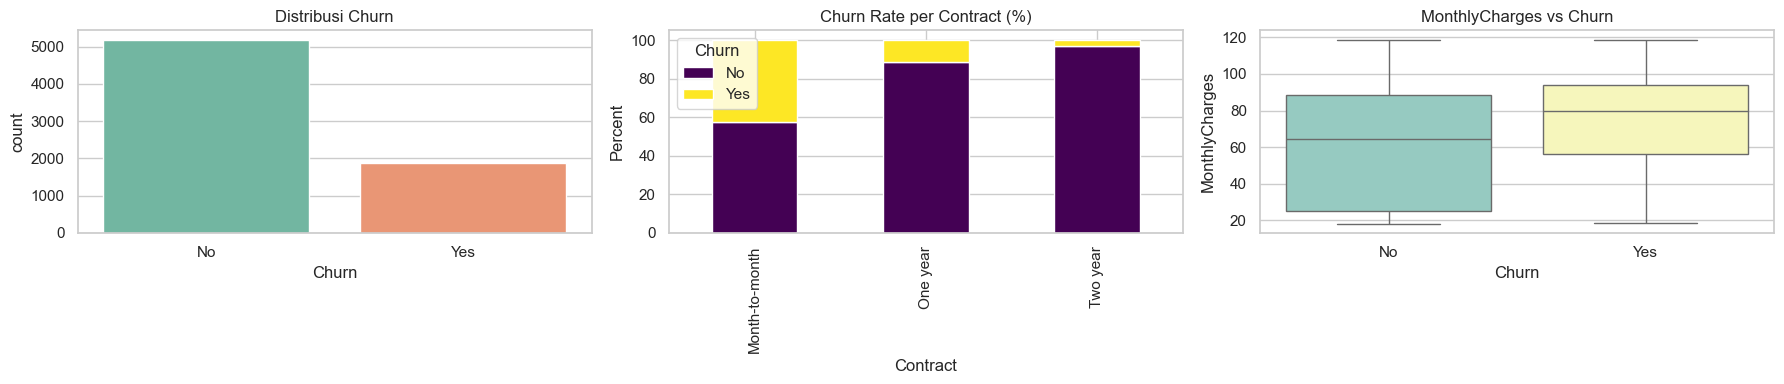

In [6]:
# 3) EDA ringkas
print('Churn rate keseluruhan:')
print((df['ChurnLabel'].mean() * 100).round(2), '%')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Churn')

if 'Contract' in df.columns:
    contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
    contract_churn.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
    axes[1].set_title('Churn Rate per Contract (%)')
    axes[1].set_ylabel('Percent')

if 'MonthlyCharges' in df.columns:
    sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2], palette='Set3')
    axes[2].set_title('MonthlyCharges vs Churn')

plt.tight_layout()
plt.show()

## Sentiment Analysis dari Customer Feedback

Pendekatan awal menggunakan **lexicon sederhana** (rule-based) agar cepat dan transparan.
Nanti bisa di-upgrade ke model NLP pretrained jika dibutuhkan.

In [7]:
# 4) Sentiment scoring (rule-based)
positive_words = {
    'good', 'great', 'satisfied', 'happy', 'excellent', 'reliable',
    'fast', 'love', 'recommend', 'helpful', 'smooth', 'affordable',
    'positive', 'best', 'convenient'
}
negative_words = {
    'bad', 'poor', 'slow', 'expensive', 'issue', 'problem', 'frustrated',
    'disappointed', 'cancel', 'churn', 'unstable', 'outage', 'worst',
    'complaint', 'delay', 'terrible', 'annoying'
}

def simple_sentiment(text: str):
    if pd.isna(text) or str(text).strip() == '':
        return 0, 'Neutral'

    tokens = re.findall(r'[a-zA-Z]+', str(text).lower())
    pos = sum(t in positive_words for t in tokens)
    neg = sum(t in negative_words for t in tokens)
    score = pos - neg

    if score > 0:
        label = 'Positive'
    elif score < 0:
        label = 'Negative'
    else:
        label = 'Neutral'
    return score, label

df[['sentiment_score', 'sentiment_label']] = df['CustomerFeedback'].apply(
    lambda x: pd.Series(simple_sentiment(x))
)
df['feedback_length'] = df['CustomerFeedback'].fillna('').str.len()

print(df[['CustomerFeedback', 'sentiment_score', 'sentiment_label']].head(3))
print('Distribusi sentiment:')
print(df['sentiment_label'].value_counts(normalize=True).round(3))

                                    CustomerFeedback  sentiment_score  \
0  I have been using the DSL internet service fro...                4   
1  I have been a customer with this company for o...                3   
2  I recently signed up for DSL internet service ...                1   

  sentiment_label  
0        Positive  
1        Positive  
2        Positive  
Distribusi sentiment:
sentiment_label
Positive    0.869
Neutral     0.070
Negative    0.061
Name: proportion, dtype: float64


In [8]:
# 5) Fitur untuk churn model
feature_cols = [
    c for c in df.columns
    if c not in ['Churn', 'ChurnLabel']
]

X = df[feature_cols].copy()
y = df['ChurnLabel'].copy()

# Pastikan kolom string menjadi object
for col in X.columns:
    if X[col].dtype == 'O':
        X[col] = X[col].astype(str)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print('Numeric features:', len(num_cols))
print('Categorical features:', len(cat_cols))
print('Contoh categorical:', cat_cols[:8])

Numeric features: 6
Categorical features: 17
Contoh categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']


In [9]:
# 6) Split + preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train)

    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_prob)

    results.append({'model': name, 'roc_auc': auc})
    fitted_pipelines[name] = (clf, y_prob, y_pred)

pd.DataFrame(results).sort_values('roc_auc', ascending=False)

,model,roc_auc
0,LogisticRegression,0.963773
1,RandomForest,0.898486


Best model: LogisticRegression
ROC AUC: 0.9638

Classification report:
              precision    recall  f1-score   support

           0      0.963     0.900     0.931      1035
           1      0.766     0.904     0.829       374

    accuracy                          0.901      1409
   macro avg      0.865     0.902     0.880      1409
weighted avg      0.911     0.901     0.904      1409



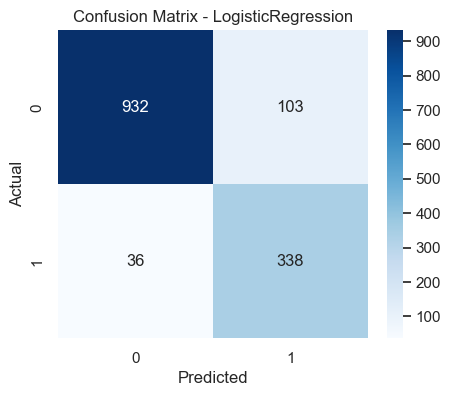

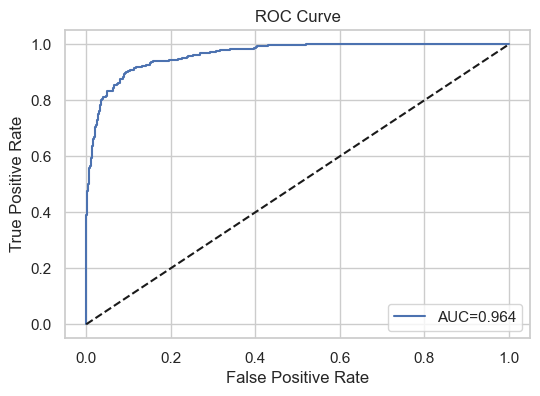

In [10]:
# 7) Evaluasi model terbaik
best_model_name = pd.DataFrame(results).sort_values('roc_auc', ascending=False).iloc[0]['model']
best_clf, best_y_prob, best_y_pred = fitted_pipelines[best_model_name]

print('Best model:', best_model_name)
print('ROC AUC:', round(roc_auc_score(y_test, best_y_prob), 4))
print('\nClassification report:')
print(classification_report(y_test, best_y_pred, digits=3))

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, best_y_prob):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

,feature,importance
40,cat__Contract_Two year,-1.790171
4,num__sentiment_score,-1.690711
17,cat__InternetService_DSL,-1.641178
5683,cat__sentiment_label_Positive,-1.593223
18,cat__InternetService_Fiber optic,1.481454
5681,cat__sentiment_label_Negative,1.227437
46,cat__PaymentMethod_Mailed check,-0.873395
3077,cat__CustomerFeedback_I have been a customer w...,0.788220
815,cat__CustomerFeedback_I have been a customer w...,0.778016
2565,cat__CustomerFeedback_I have been a customer w...,0.769268


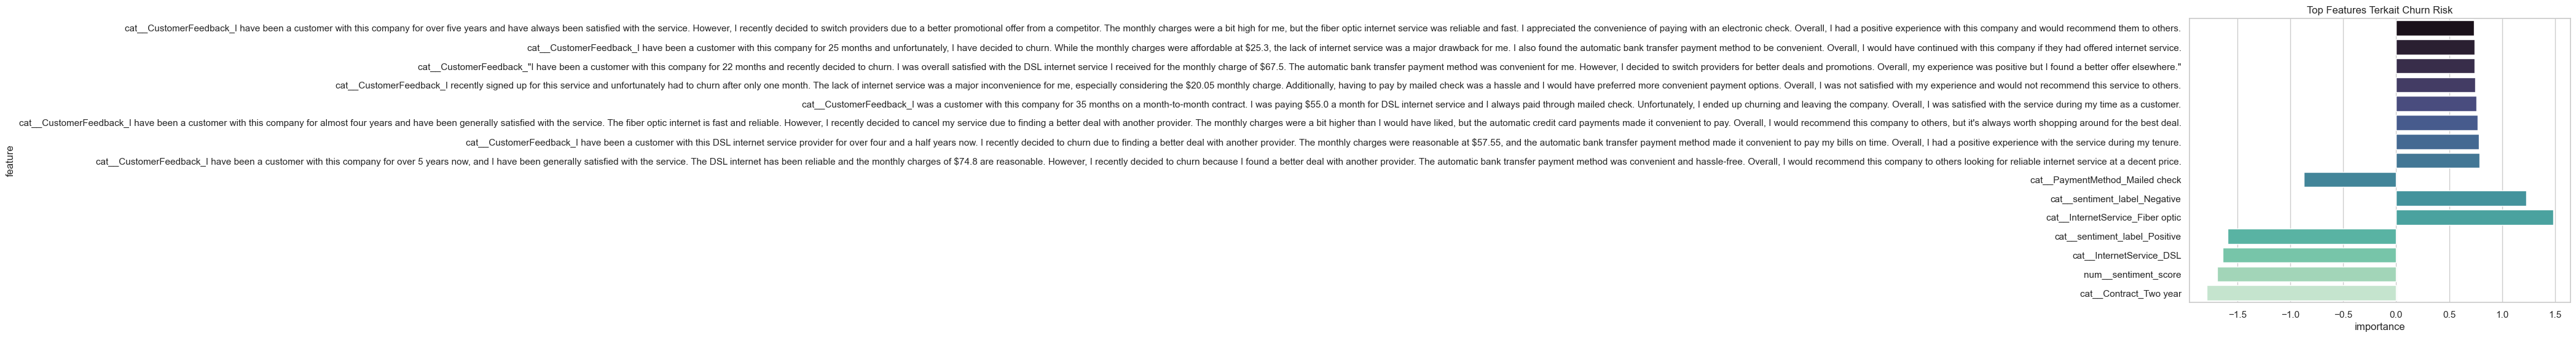

In [11]:
# 8) Actionable insight: faktor utama churn
# Gunakan feature importance dari model terbaik
if best_model_name == 'LogisticRegression':
    model = best_clf.named_steps['model']
    feature_names = best_clf.named_steps['preprocess'].get_feature_names_out()
    coef = model.coef_[0]

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': coef,
        'abs_importance': np.abs(coef)
    }).sort_values('abs_importance', ascending=False)

    top_risk = importance_df.head(15)
    display(top_risk[['feature', 'importance']])

else:
    model = best_clf.named_steps['model']
    feature_names = best_clf.named_steps['preprocess'].get_feature_names_out()
    imp = model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': imp
    }).sort_values('importance', ascending=False)

    top_risk = importance_df.head(15)
    display(top_risk)

plt.figure(figsize=(8,6))
plot_df = top_risk.sort_values('importance' if best_model_name == 'RandomForest' else 'abs_importance')
x_col = 'importance' if best_model_name == 'RandomForest' else 'importance'
sns.barplot(data=plot_df, x=x_col, y='feature', palette='mako')
plt.title('Top Features Terkait Churn Risk')
plt.tight_layout()
plt.show()

In [12]:
# 9) Decision support: risk tier + rekomendasi tindakan
all_probs = best_clf.predict_proba(X)[:, 1]
output = df.copy()
output['churn_probability'] = all_probs

def risk_tier(p):
    if p >= 0.70:
        return 'High'
    if p >= 0.40:
        return 'Medium'
    return 'Low'

def action_plan(row):
    tier = row['risk_tier']
    sentiment = row['sentiment_label']
    contract = str(row.get('Contract', ''))

    if tier == 'High':
        if sentiment == 'Negative':
            return 'Priority retention call + service recovery + personalized discount 15-20%'
        return 'Retention offer + contract upgrade incentive'
    if tier == 'Medium':
        if contract == 'Month-to-month':
            return 'Offer migration to 1-year contract + value bundle promo'
        return 'Targeted promo and check-in via CRM campaign'
    return 'Maintain engagement with loyalty content; no urgent action'

output['risk_tier'] = output['churn_probability'].apply(risk_tier)
output['recommended_action'] = output.apply(action_plan, axis=1)

priority_cols = [c for c in ['Contract', 'MonthlyCharges', 'tenure', 'sentiment_label', 'churn_probability', 'risk_tier', 'recommended_action'] if c in output.columns]

priority_view = output.sort_values('churn_probability', ascending=False)[priority_cols].head(15)
priority_view

,Contract,MonthlyCharges,tenure,sentiment_label,churn_probability,risk_tier,recommended_action
6068,Month-to-month,95.05,50,Negative,1.0,High,Priority retention call + service recovery + p...
3406,Month-to-month,95.10,3,Negative,1.0,High,Priority retention call + service recovery + p...
383,Month-to-month,90.85,1,Negative,1.0,High,Priority retention call + service recovery + p...
2838,Month-to-month,99.00,13,Negative,1.0,High,Priority retention call + service recovery + p...
6143,Month-to-month,84.20,51,Negative,1.0,High,Priority retention call + service recovery + p...
2009,Month-to-month,103.85,53,Negative,1.0,High,Priority retention call + service recovery + p...
6380,One year,105.65,4,Negative,1.0,High,Priority retention call + service recovery + p...
6989,Month-to-month,79.90,3,Negative,1.0,High,Priority retention call + service recovery + p...
1662,Month-to-month,70.25,1,Negative,1.0,High,Priority retention call + service recovery + p...
6542,Month-to-month,69.60,2,Negative,1.0,High,Priority retention call + service recovery + p...


In [13]:
# 10) Simpan artefak
joblib.dump(best_clf, 'dataset/churn_intelligence_model.pkl')
output.to_csv('dataset/churn_intelligence_output.csv', index=False)

print('Model tersimpan: dataset/churn_intelligence_model.pkl')
print('Output skor & rekomendasi: dataset/churn_intelligence_output.csv')
print(output[['risk_tier']].value_counts(normalize=True).rename('proporsi').round(3))

Model tersimpan: dataset/churn_intelligence_model.pkl
Output skor & rekomendasi: dataset/churn_intelligence_output.csv
risk_tier
Low          0.677
High         0.263
Medium       0.061
Name: proporsi, dtype: float64


## Next Upgrade (Opsional)
- Ganti sentiment rule-based menjadi model NLP pretrained (IndoBERT / multilingual model)
- Tambah SHAP untuk local explanation per customer
- Integrasi ke dashboard BI untuk monitoring churn harian